Learned rule: Female(x)  ->  Daughter(x, y)

Round 0: (most general)                      | pos_covered=2  neg_covered=2
Round 1: Female(x)                           | pos_covered=2  neg_covered=0


C:\Users\user\AppData\Local\Temp\ipykernel_14628\219471624.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


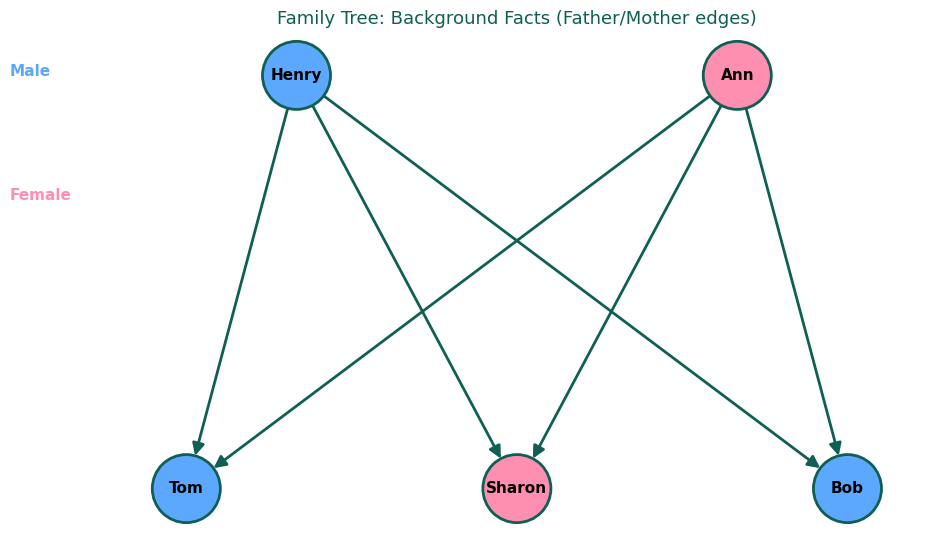

C:\Users\user\AppData\Local\Temp\ipykernel_14628\219471624.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


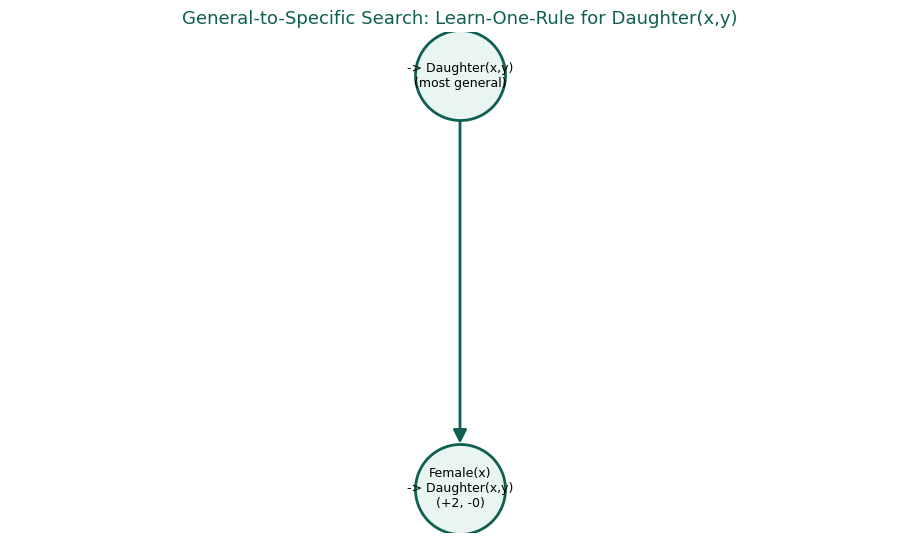

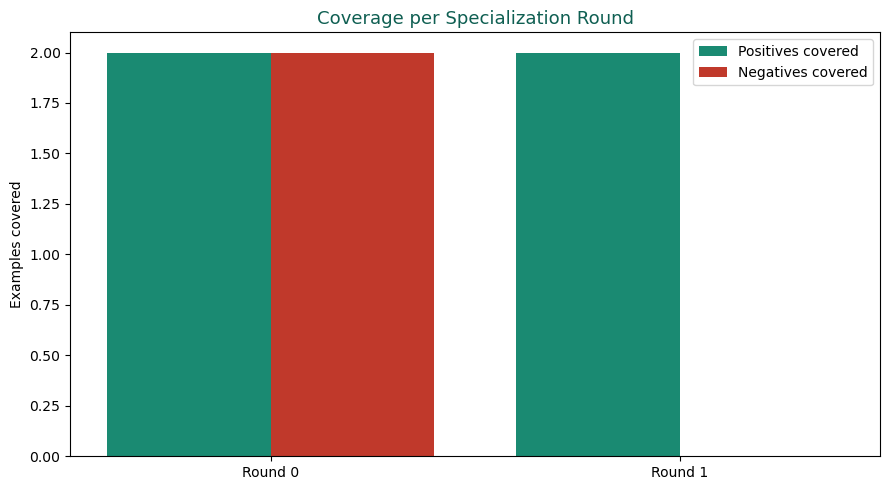

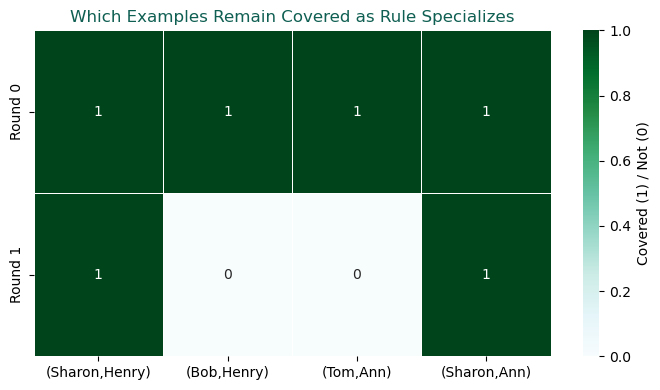


Final learned rule: Female(x)  ->  Daughter(x, y)

Verification against training data:
       Instance Female(x) Rule Result Class
(Sharon, Henry)         T     Covered     +
   (Bob, Henry)         F Not covered     -
     (Tom, Ann)         F Not covered     -
  (Sharon, Ann)         T     Covered     +


In [2]:
!pip install networkx matplotlib pandas seaborn -q

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ============================================================
# 1. DATA - Family relationships (matches slide 8)
# ============================================================
facts = {
    "Father": {("Henry", "Tom"), ("Henry", "Sharon"), ("Henry", "Bob")},
    "Mother": {("Ann", "Tom"), ("Ann", "Sharon"), ("Ann", "Bob")},
    "Male":   {("Henry",), ("Tom",), ("Bob",)},
    "Female": {("Ann",), ("Sharon",)},
}

examples = [
    ("Sharon", "Henry", True),
    ("Bob",    "Henry", False),
    ("Tom",    "Ann",   False),
    ("Sharon", "Ann",   True),
]

candidate_literals = {
    "Father(y,x)": lambda x, y: (y, x) in facts["Father"],
    "Mother(y,x)": lambda x, y: (y, x) in facts["Mother"],
    "Male(x)":     lambda x, y: (x,) in facts["Male"],
    "Female(x)":   lambda x, y: (x,) in facts["Female"],
}

# ============================================================
# 2. LEARN-ONE-FIRST-ORDER-RULE (general-to-specific search, slide 14)
# ============================================================
def evaluate_rule(literal_names, examples):
    pos, neg, covered = 0, 0, []
    for x, y, label in examples:
        satisfied = all(candidate_literals[lit](x, y) for lit in literal_names)
        if satisfied:
            covered.append((x, y, label))
            if label:
                pos += 1
            else:
                neg += 1
    return pos, neg, covered

def learn_one_rule(examples, candidate_literals):
    rule_body = []
    history = []
    round_num = 0
    while True:
        pos, neg, covered = evaluate_rule(rule_body, examples)
        history.append({
            "round": round_num,
            "rule": " AND ".join(rule_body) if rule_body else "(most general)",
            "pos_covered": pos,
            "neg_covered": neg,
        })
        if neg == 0:
            break

        scores = {}
        for lit in candidate_literals:
            if lit in rule_body:
                continue
            trial_body = rule_body + [lit]
            p, n, _ = evaluate_rule(trial_body, examples)
            scores[lit] = (p - n, p, n)

        best_lit = max(scores, key=lambda l: scores[l][0])
        rule_body.append(best_lit)
        round_num += 1

    final_pos, final_neg, final_covered = evaluate_rule(rule_body, examples)
    return rule_body, history, final_covered

rule_body, history, final_covered = learn_one_rule(examples, candidate_literals)
rule_str = " AND ".join(rule_body) + "  ->  Daughter(x, y)"
print("Learned rule:", rule_str)
print()
for h in history:
    print("Round {}: {:35s} | pos_covered={}  neg_covered={}".format(
        h["round"], h["rule"], h["pos_covered"], h["neg_covered"]))

# ============================================================
# 3. VISUALIZATION 1 - Family Tree (pictorial representation, slide 8)
# ============================================================
FT = nx.DiGraph()
FT.add_edges_from([
    ("Henry", "Tom"), ("Henry", "Sharon"), ("Henry", "Bob"),
    ("Ann", "Tom"), ("Ann", "Sharon"), ("Ann", "Bob"),
])

pos_ft = {
    "Henry": (-1, 1), "Ann": (1, 1),
    "Tom": (-1.5, 0), "Sharon": (0, 0), "Bob": (1.5, 0),
}

male_color, female_color = "#5da8ff", "#ff8fb0"
node_colors = []
for n in FT.nodes():
    if n in ("Henry", "Tom", "Bob"):
        node_colors.append(male_color)
    else:
        node_colors.append(female_color)

plt.figure(figsize=(8, 5))
nx.draw(
    FT, pos_ft, with_labels=True, node_size=2400,
    node_color=node_colors, edgecolors="#0f5f52", linewidths=2,
    font_size=11, font_weight="bold", arrows=True, arrowsize=18,
    edge_color="#0f5f52", width=2
)
plt.title("Family Tree: Background Facts (Father/Mother edges)", fontsize=13, color="#0f5f52")
plt.text(-2.3, 1, "Male", color=male_color, fontsize=11, fontweight="bold")
plt.text(-2.3, 0.7, "Female", color=female_color, fontsize=11, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

# ============================================================
# 4. VISUALIZATION 2 - Search Lattice (general -> specific), slide 13
# ============================================================
G = nx.DiGraph()
node_labels = {}
prev_node = "root"
G.add_node(prev_node)
node_labels[prev_node] = "-> Daughter(x,y)\n(most general)"

for i, h in enumerate(history[1:], start=1):
    node = "step{}".format(i)
    G.add_node(node)
    G.add_edge(prev_node, node)
    node_labels[node] = "{}\n-> Daughter(x,y)\n(+{}, -{})".format(
        h["rule"], h["pos_covered"], h["neg_covered"])
    prev_node = node

plt.figure(figsize=(9, 5))
pos = {n: (0, -i) for i, n in enumerate(G.nodes())}
nx.draw(
    G, pos, with_labels=False, node_size=4200,
    node_color="#e8f5f0", edgecolors="#0f5f52", linewidths=2,
    arrows=True, arrowsize=20, edge_color="#0f5f52", width=2
)
for n, (px, py) in pos.items():
    plt.text(px, py, node_labels[n], ha="center", va="center", fontsize=9, wrap=True)
plt.title("General-to-Specific Search: Learn-One-Rule for Daughter(x,y)", fontsize=13, color="#0f5f52")
plt.axis("off")
plt.tight_layout()
plt.show()

# ============================================================
# 5. VISUALIZATION 3 - Per-round coverage bars
# ============================================================
rounds = [h["round"] for h in history]
pos_vals = [h["pos_covered"] for h in history]
neg_vals = [h["neg_covered"] for h in history]

x_idx = range(len(rounds))
plt.figure(figsize=(9, 5))
plt.bar([i - 0.2 for i in x_idx], pos_vals, width=0.4, label="Positives covered", color="#1a8a72")
plt.bar([i + 0.2 for i in x_idx], neg_vals, width=0.4, label="Negatives covered", color="#c0392b")
plt.xticks(list(x_idx), ["Round {}".format(r) for r in rounds])
plt.ylabel("Examples covered")
plt.title("Coverage per Specialization Round", fontsize=13, color="#0f5f52")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 6. VISUALIZATION 4 - Coverage evolution heatmap (examples x rounds)
# ============================================================
example_ids = ["({},{})".format(x, y) for x, y, _ in examples]
heat_data = []
for h_i in range(len(history)):
    body = rule_body[:h_i]
    row = []
    for x, y, label in examples:
        satisfied = all(candidate_literals[lit](x, y) for lit in body)
        row.append(1 if satisfied else 0)
    heat_data.append(row)

heat_df = pd.DataFrame(heat_data, index=["Round {}".format(h["round"]) for h in history], columns=example_ids)

plt.figure(figsize=(7, 4))
sns.heatmap(heat_df, annot=True, cmap="BuGn", cbar_kws={"label": "Covered (1) / Not (0)"},
            linewidths=0.5, linecolor="white")
plt.title("Which Examples Remain Covered as Rule Specializes", fontsize=12, color="#0f5f52")
plt.tight_layout()
plt.show()

# ============================================================
# 7. Final verification table (matches slide 18)
# ============================================================
print()
print("Final learned rule:", rule_str)
print()
print("Verification against training data:")
verify_rows = []
for x, y, label in examples:
    lit_results = {lit: candidate_literals[lit](x, y) for lit in rule_body}
    satisfied = all(lit_results.values())
    row = {"Instance": "({}, {})".format(x, y)}
    for lit, val in lit_results.items():
        row[lit] = "T" if val else "F"
    row["Rule Result"] = "Covered" if satisfied else "Not covered"
    row["Class"] = "+" if label else "-"
    verify_rows.append(row)
verify_df = pd.DataFrame(verify_rows)
print(verify_df.to_string(index=False))